In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import spacy
import glob
from constants import BASE_PATH
import json
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import text_cleaning as tc
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import itertools
from analysis_utils import *

In [3]:
from tqdm.auto import tqdm
tqdm.pandas()

In [4]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [16]:
from constants import (
    JIBARO_WORDS, GIBARO_WORDS, CAMPESINO_WORDS, 
    LCCN_TO_NAME, BASE_PATH
)

import matplotlib.ticker as mtick
from matplotlib.ticker import MultipleLocator

# Load Data

In [6]:
data_df = pd.read_pickle('relevant_docs_df.pkl')

In [7]:
data_df.sample(3)

,,lccn,date,year,month,day,edition,sequence,total_tokens,title,jibaro_counts,...,surrounding_text_gibar,word_type,label,relvent_gibar_doc_score,relvent_jibar_doc_score,relevant_jibar_doc,relevant_gibar_doc,relevant_campesin_doc,is_relevant,doc_length
link,text_id,,,,,,,,,,,,,,,,,,,,,
https://chroniclingamerica.loc.gov/lccn/sn91099747/1897-01-13/ed-1/seq-4/,TB.0049.114,sn91099747,1897-01-13,1897,01,13,ed-1,seq-4,2715,La correspondencia de Puerto Rico,0,...,(),NaN,NaN,0.793521,0.309358,False,False,True,True,468
https://chroniclingamerica.loc.gov/lccn/sn91099739/1896-11-22/ed-1/seq-2/,P2_TB00023,sn91099739,1896-11-22,1896,11,22,ed-1,seq-2,8408,Boletín mercantil de Puerto Rico,3,...,(),NaN,NaN,0.824126,0.283253,False,False,True,True,242
https://chroniclingamerica.loc.gov/lccn/sn91099739/1903-09-22/ed-1/seq-2/,P2_TB00005,sn91099739,1903-09-22,1903,09,22,ed-1,seq-2,3996,Boletín mercantil de Puerto Rico,0,...,(),NaN,NaN,0.788497,0.202847,False,False,True,True,862


In [8]:
def _doc_agg(g):
    jibar_sums = g.loc[g['relevant_jibar_doc']]['contains_search_word_jibar'].sum()
    gibar_sums = g.loc[g['relevant_gibar_doc']]['contains_search_word_gibar'].sum()
    campesin_sums =  g.loc[g['relevant_campesin_doc']]['contains_search_word_campesin'].sum()
    l = g['doc_length'].sum()
    
    return pd.Series({
        'year': g.iloc[0]['year'],
        'title': g.iloc[0]['title'],
        'jibar_freq': jibar_sums / l,
        'gibar_freq': gibar_sums / l,
        'campesin_freq': campesin_sums / l,
        'jibaro_gibaro_freq': (jibar_sums + gibar_sums)/l,
        'contains_jibar': jibar_sums > 0,
        'contains_gibar': gibar_sums > 0,
        'contains_campesin': campesin_sums > 0,
        'contains_jibaro_gibaro': (jibar_sums + gibar_sums) > 0,
        'jibar_sum': jibar_sums,
        'gibar_sum': gibar_sums,
        'campesin_sum': campesin_sums,
        'jibaro_gibaro_sum': jibar_sums + gibar_sums,
        'doc_length': l
    })
        

per_doc_df = (
    data_df
    .reset_index()
    .groupby('link')
    .progress_apply(_doc_agg, include_groups=False)
)

  0%|          | 0/7008 [00:00<?, ?it/s]

In [9]:
per_doc_df.sample(5)

,year,title,jibar_freq,gibar_freq,campesin_freq,jibaro_gibaro_freq,contains_jibar,contains_gibar,contains_campesin,contains_jibaro_gibaro,jibar_sum,gibar_sum,campesin_sum,jibaro_gibaro_sum,doc_length
link,,,,,,,,,,,,,,,
https://chroniclingamerica.loc.gov/lccn/sn91099747/1894-09-05/ed-1/seq-2/,1894,La correspondencia de Puerto Rico,0.001776,0.0,0.000000,0.001776,True,False,False,True,2,0,0,2,1126
https://chroniclingamerica.loc.gov/lccn/sn91099747/1896-04-21/ed-1/seq-2/,1896,La correspondencia de Puerto Rico,0.000000,0.0,0.001027,0.000000,False,False,True,False,0,0,1,0,974
https://chroniclingamerica.loc.gov/lccn/sn91099747/1903-11-27/ed-1/seq-2/,1903,La correspondencia de Puerto Rico,0.000000,0.0,0.002778,0.000000,False,False,True,False,0,0,1,0,360
https://chroniclingamerica.loc.gov/lccn/sn86077151/1923-06-20/ed-1/seq-12/,1923,El Mundo,0.000000,0.0,0.004003,0.000000,False,False,True,False,0,0,5,0,1249
https://chroniclingamerica.loc.gov/lccn/sn86077151/1920-01-03/ed-1/seq-3/,1920,El Mundo,0.000000,0.0,0.002123,0.000000,False,False,True,False,0,0,1,0,471


In [17]:
per_doc_df.columns

Index(['year', 'title', 'jibar_freq', 'gibar_freq', 'campesin_freq',
       'jibaro_gibaro_freq', 'contains_jibar', 'contains_gibar',
       'contains_campesin', 'contains_jibaro_gibaro', 'jibr_sum', 'gibar_sum',
       'campesin_sum', 'jibaro_gibaro_sum', 'doc_length'],
      dtype='object')

In [10]:
plot_df = (
    per_doc_df
    .reset_index()
    .groupby(['year', 'title'])[['jibar_sum', 'gibar_sum', 'campesin_sum', 'jibaro_gibaro_sum']]
    .sum()
    .reset_index()
)
plot_df.columns = ['year', 'title', 'jibar_mentions', 'gibar_mentions', 'campasin_mentions', 'jibar_gibar_mentions']
plot_df.columns

Index(['year', 'title', 'jibar_mentions', 'gibar_mentions',
       'campasin_mentions', 'jibar_gibar_mentions'],
      dtype='object')

In [40]:
summary_df = plot_df.groupby('title')[['jibar_mentions', 'gibar_mentions', 'campasin_mentions', 'jibar_gibar_mentions']].sum()
summary_df

,jibar_mentions,gibar_mentions,campasin_mentions,jibar_gibar_mentions
title,,,,
Boletín mercantil de Puerto Rico,623,11,1858,634
El Imparcial,263,1,695,264
El Mundo,727,3,1792,730
Gazeta de Puerto-Rico.,25,2,169,27
La correspondencia de Puerto Rico,863,29,2327,892
La democracia,116,5,379,121


In [41]:
summary_df.sum()

jibar_mentions          2617
gibar_mentions            51
campasin_mentions       7220
jibar_gibar_mentions    2668
dtype: int64

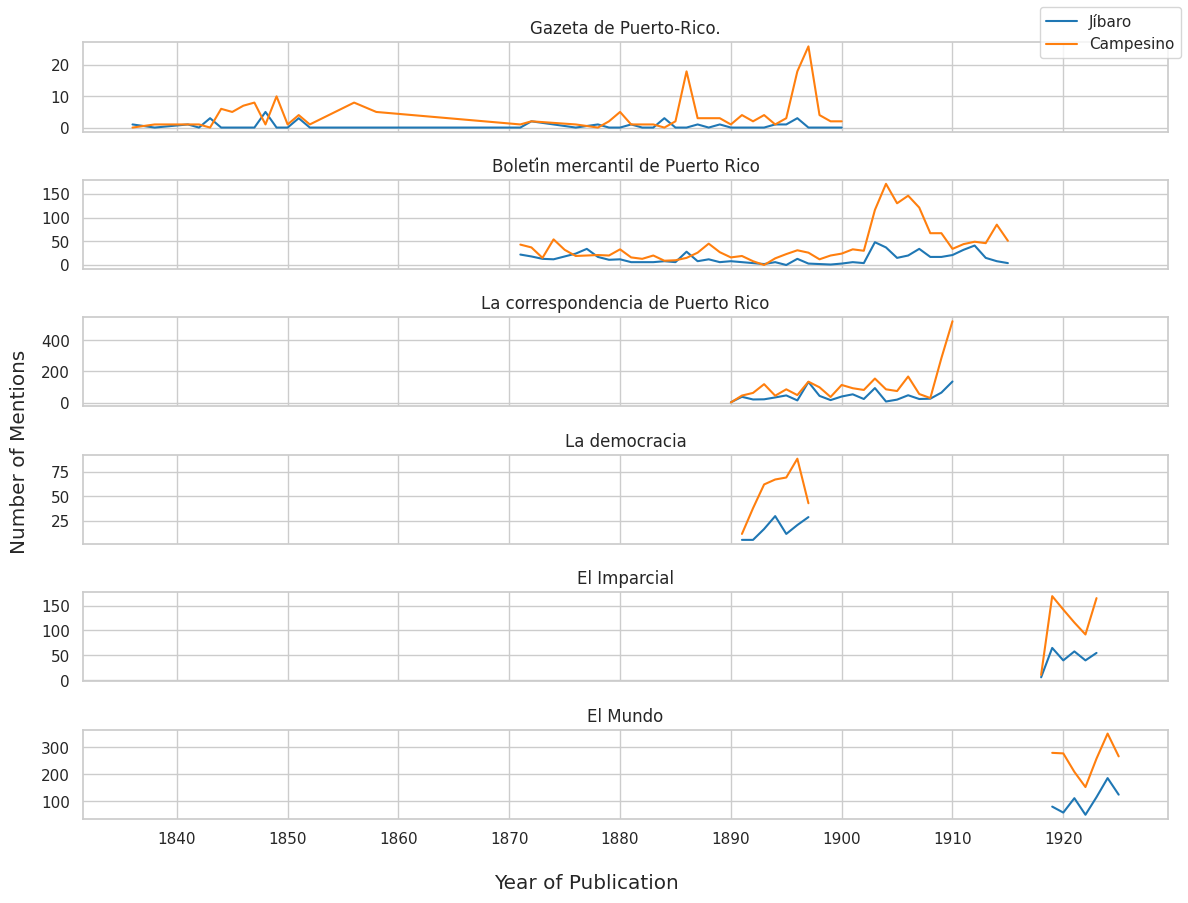

In [21]:
sns.set_theme(style="whitegrid")


plot_df['year'] = pd.to_numeric(plot_df['year'])
freq_colors = {
    'jibar_gibar_mentions': 'tab:blue',
    'campasin_mentions': 'tab:orange',
}
titles = plot_df['title'].unique()
n_titles = len(titles)

fig, axes = plt.subplots(
    n_titles,
    1,
    figsize=(12, 1.5 * n_titles),
    sharex=True
)

for ax, title in zip(axes, titles):
    df_t = plot_df[plot_df['title'] == title]

    ax.plot(
        df_t['year'],
        df_t['jibar_gibar_mentions'],
        color=freq_colors['jibar_gibar_mentions'],
        label='Jíbaro'
    )

    ax.plot(
        df_t['year'],
        df_t['campasin_mentions'],
        color=freq_colors['campasin_mentions'],
        label='Campesino'
    )
    ax.locator_params(axis='y', nbins=4)
    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.set_title(title)

fig.supxlabel('Year of Publication')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.supylabel('Number of Mentions')
plt.tight_layout()

plt.show()


In [27]:
dataset_df = pd.read_pickle('prelim_analysis_df.pkl').reset_index()

In [38]:
summary_df = dataset_df.groupby('title')['date'].agg(['count', 'nunique'])
summary_df.columns = ['num_pages', 'num_issues']
summary_df['pages_per_issue'] = summary_df['num_pages']/summary_df['num_issues']
summary_df

,num_pages,num_issues,pages_per_issue
title,,,
Boletín mercantil de Puerto Rico,49955,8581,5.821583
El Imparcial,13273,1464,9.066257
El Mundo,21237,2092,10.151530
Gazeta de Puerto-Rico.,46329,8601,5.386467
La correspondencia de Puerto Rico,26880,6526,4.118909
La democracia,6091,1528,3.986257


In [39]:
summary_df['num_issues'].sum()

np.int64(28792)

In [42]:
dataset_df['total_tokens'].sum()

np.int64(629424801)